# CSE 579 Homework 2: Reinforcement Learning

In this assignment, you will implement:
1. **Policy Gradient (PG)** with a baseline
2. **Actor-Critic (AC)** with a single Q-function
3. **Soft Actor-Critic (SAC)** with double Q + entropy temperature

You will train and evaluate on **InvertedPendulum-v4**, and additionally run AC + SAC on **Ant-v4**.


**Getting started:** Click **File > Save a copy in Drive** to create your own editable copy of this notebook. Do not edit the original.


## 1. Setup and Installation


In [1]:
# Clone the homework repository
!git clone https://github.com/WEIRDLabUW/CSE579-hw2.git
!cp -r CSE579-hw2/* .
!cp -r CSE579-hw2/.gitignore .


Cloning into 'CSE579-hw2'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 88 (delta 50), reused 63 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 37.17 KiB | 4.65 MiB/s, done.
Resolving deltas: 100% (50/50), done.


In [ ]:
# Install system dependencies (for MuJoCo rendering)
!apt-get install -y \
    libgl1-mesa-dev \
    libgl1-mesa-glx \
    libglew-dev \
    libosmesa6-dev \
    software-properties-common \
    patchelf

# Install PyTorch with CUDA support
!pip install -q \
    torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
    --extra-index-url https://download.pytorch.org/whl/cu124

# Install gymnasium + mujoco + imageio for video rendering.
# (We do not need gymnasium-robotics — it pins mujoco<3.0, which lacks prebuilt
# wheels for Colab's Python and forces a source build that fails.)
!pip install -q \
    gymnasium==0.29.1 \
    mujoco \
    "imageio[ffmpeg]" \
    matplotlib \
    "numpy>=1.24,<2.0" \
    tqdm

import os
os.environ['LD_PRELOAD'] = ':/usr/lib/x86_64-linux-gnu/libGLEW.so'

# Restart the runtime so the new numpy version takes effect.
# After restart, skip this cell and continue from the next one.
os.kill(os.getpid(), 9)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
software-properties-common is already the newest version (0.99.22.9).
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
The following additional packages will be installed:
  libegl-dev libgl-dev libgles-dev libgles1 libglew2.2 libglu1-mesa
  libglu1-mesa-dev libglvnd-core-dev libglvnd-dev libglx-dev libopengl-dev
  libosmesa6
Suggested packages:
  glew-utils
The following NEW packages will be installed:
  libegl-dev libgl-dev libgl1-mesa-dev libgles-dev libgles1 libglew-dev
  libglew2.2 libglu1-mesa libglu1-mesa-dev libglvnd-core-dev libglvnd-dev
  libglx-dev libopengl-dev libosmesa6 libosmesa6-dev patchelf
0 upgraded, 16 newly installed, 0 to remove and 100 not upgraded.
Need to get 4,275 kB of archives.
After this operation, 20.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libglx-dev amd64 1.4.0-1 [14.1 kB]
Get:

**Important:** The cell above restarts the runtime. After it restarts, skip cells 1 & 2 above and continue from the cell below.


In [1]:
# Re-set env var (lost after runtime restart)
import os
os.environ['LD_PRELOAD'] = ':/usr/lib/x86_64-linux-gnu/libGLEW.so'
os.environ['MUJOCO_GL'] = 'egl'


## 2. Imports and Device Setup


In [47]:
import random

import gymnasium as gym
import numpy as np
import torch
import torch.nn.functional as F
from torch import optim

from agents import GenericACAgent, train_agent
from networks import PGPolicy, PGBaseline
from rollouts import evaluate, evaluate_agent, rollout
from utils import ReplayBuffer, log_density
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device:', device)


using device: cuda


## 3. Policy Gradient (PG)

Fill in the TODOs in `train_model` below. You'll need to compute the return-to-go, then train the baseline by regression and the policy via the policy-gradient surrogate.


In [67]:
def train_model(policy, baseline, trajs, policy_optim, baseline_optim, device, gamma=0.99, baseline_train_batch_size=64,
                baseline_num_epochs=5):

    states_all = []
    actions_all = []
    returns_all = []
    for traj in trajs:
        states_singletraj = traj['observations']
        actions_singletraj = traj['actions']
        rewards_singletraj = traj['rewards']
        returns_singletraj = np.zeros_like(rewards_singletraj)
        #========== TODO: start ==========
        # Compute the return to go on the current batch of trajectories
        # Hint: Go through all the trajectories in trajs and compute their return to go: discounted sum of rewards from that timestep to the end.
        # Hint: This is easy to do if you go backwards in time and sum up the reward as a running sum.
        # Hint: Remember that return to go is return = r[t] + gamma*r[t+1] + gamma^2*r[t+2] + .... Don't forget the discount!

        n = len(traj['rewards'])
        returns_singletraj[n - 1] = rewards_singletraj[n - 1]
        for i in range(n - 2, -1, -1):
          returns_singletraj[i] = (gamma * returns_singletraj[i+1]) + rewards_singletraj[i]


        # returns_singletraj = ...
        #========== TODO: END ==========
        states_all.append(states_singletraj)
        actions_all.append(actions_singletraj)
        returns_all.append(returns_singletraj)
    states = np.concatenate(states_all)
    actions = np.concatenate(actions_all)
    returns = np.concatenate(returns_all)

    # TODO: Normalize the returns by subtracting mean and dividing by std
    # Hint: (return - return.mean()) / (return.std() + EPS), where EPS is a small constant for numerics
    # TODO start
    EPS = 1e-7
    returns = (returns - returns.mean()) / (returns.std() + EPS)
    # TODO end

    criterion = torch.nn.MSELoss()
    n = len(states)
    arr = np.arange(n)
    for epoch in range(baseline_num_epochs):
        np.random.shuffle(arr)
        for i in range(n // baseline_train_batch_size):
            batch_index = arr[baseline_train_batch_size * i: baseline_train_batch_size * (i + 1)]
            batch_index = torch.LongTensor(batch_index).to(device)
            inputs = torch.Tensor(states).to(device)[batch_index]
            target = torch.Tensor(returns).to(device)[batch_index]

            #========== TODO: start ==========
            # Train baseline by regressing onto returns.
            # Hint: Regress the baseline from each state onto the above
            # computed return to go. You can use similar code to behavior cloning to do so. This should be
            # 2 lines of code
            # Hint: baseline is a callable function

            baseline_prediction = baseline(inputs)
            loss = criterion(baseline_prediction, target)

            #========== TODO: END ==========
            baseline_optim.zero_grad()
            loss.backward()
            baseline_optim.step()

    action, std, logstd = policy(torch.Tensor(states).to(device))
    log_policy = log_density(torch.Tensor(actions).to(device), policy.mu, std, logstd)
    baseline_pred = baseline(torch.from_numpy(states).float().to(device))
    #========== TODO: start ==========
    # Train policy by optimizing surrogate objective: -log prob * (return - baseline)
    # Hint: log_policy and baseline_pred are already computed above; use them directly.
    # Hint: Policy gradient is given by: \grad log prob(a|s)* (return - baseline)
    # Hint: Then simply compute the surrogate objective by taking the objective as -log prob * (return - baseline)
    # Hint: You can then use standard pytorch machinery to take *one* gradient step on the policy

    baseline_pred = baseline_pred.detach()
    returns = torch.Tensor(returns).to(device)
    advantages = returns - baseline_pred
    # advantages = returns
    loss = (-log_policy * advantages).sum()

    #========== TODO: END ==========
    policy_optim.zero_grad()
    loss.backward()
    policy_optim.step()

    del states, actions, returns, states_all, actions_all, returns_all


# Training loop for policy gradient
def simulate_policy_pg(env, policy, baseline, num_epochs=200, batch_size=100,
                       gamma=0.99, baseline_train_batch_size=64, baseline_num_epochs=5, print_freq=10, device = "cuda", render=False):
    policy_optim = optim.Adam(policy.parameters())
    baseline_optim = optim.Adam(baseline.parameters())

    print("Note: No subtractling baseline and not normalizing returns")

    rewards, epochs = [], []

    for iter_num in range(num_epochs):
        sample_trajs = []

        # Sampling trajectories
        for it in range(batch_size):
            sample_traj = rollout(
                env,
                policy,
                render=False)
            sample_trajs.append(sample_traj)

        # Logging returns occasionally
        if iter_num % print_freq == 0:
            rewards_np = np.mean(np.asarray([traj['rewards'].sum() for traj in sample_trajs]))
            path_length = np.max(np.asarray([traj['rewards'].shape[0] for traj in sample_trajs]))
            print("Episode: {}, reward: {}, max path length: {}".format(iter_num, rewards_np, path_length))
            rewards.append(rewards_np)
            epochs.append(iter_num)

        # Training model
        train_model(policy, baseline, sample_trajs, policy_optim, baseline_optim, device, gamma=gamma,
                    baseline_train_batch_size=baseline_train_batch_size, baseline_num_epochs=baseline_num_epochs)

    return rewards, epochs


## 4. Actor-Critic (AC)

Fill in the TODOs in `ActorCriticAgent` below.


In [74]:
class ActorCriticAgent(GenericACAgent):
    def update_actor(self, obs):
        dist = self.actor(obs)
        # The .rsample() is used to sample using the reparameterization trick to allow for backpropagation
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(-1, keepdim=True)
        #========== TODO: start ==========
        # Implement the actor update
        # Compute the Q values of the action using self.critic(obs, action). In this case it is a single instead of
        # double Q function so you do not need to take a minimum.
        # The policy loss is the mean over the negative Q values i.e we want to maximize the Q values

        action_Q = self.critic(obs, action)
        actor_loss = -action_Q.mean()

        #========== TODO: end ==========
        # optimize the actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        return actor_loss.item(), 0, 0

    def update_critic(self, obs, action, reward, next_obs, not_done_no_max):
        #========== TODO: start ==========
        # Train the single Q function:
        # Hint: Step 1: Compute current Q predictions using the obs and action and self.critic()
        # Hint: Step 2: Compute q targets using reward + critic_target * not_done_no_max for next_obs and
        # next actions sampled from the current policy. Use torch.no_grad() for this step to disable
        # gradient flow to the critic_target and the actor.
        # Hint: Step 3: Compute Bellman error as mean squared error between q_predictions and q_targets

        current_Q_pred = self.critic(obs, action)

        with torch.no_grad():
          next_dist = self.actor(next_obs)
          next_action = next_dist.rsample()

          next_Q = self.critic_target(next_obs, next_action)
          # next_Q = self.critic(next_obs, next_action)
          target_Q = reward + not_done_no_max * self.discount * next_Q

        criterion = torch.nn.MSELoss()
        critic_loss = criterion(current_Q_pred, target_Q)

        #========== TODO: end ==========
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        return critic_loss.item()

## 5. Soft Actor-Critic (SAC)

Fill in the TODOs in `SACAgent` below.


In [75]:
class SACAgent(GenericACAgent):
    def update_actor(self, obs):
        #========== TODO: start ==========
        # Sample actions and the log_prob of the actions from the actor given obs. Hint: This is the same as AC agent.
        # Get the two Q values from the double Q function critic and take the minimum value. Then calculate the actor loss which
        # is defined by self.alpha * log_prob - actor_Q. Make sure that gradient does not flow through the alpha parameter.

        dist = self.actor(obs)
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(-1, keepdim=True)

        with torch.no_grad():
          a = self.alpha

        # print(self.critic(obs, action))
        q1, q2 = self.critic(obs, action)
        if q1.mean() < q2.mean():
          actor_Q = q1
        else:
          actor_Q = q2

        actor_loss = (a * log_prob - actor_Q).mean()


        #========== TODO: end ==========
        # optimize the actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Update the temperature parameter to achieve entropy close to the target entropy
        self.log_alpha_optimizer.zero_grad()
        alpha_loss = (self.alpha *
                      (-log_prob - self.target_entropy).detach())
        alpha_loss = alpha_loss.mean()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()
        return actor_loss.item(), -log_prob.mean().item(), alpha_loss.item()

    def update_critic(self, obs, action, reward, next_obs, not_done_no_max):
        #========== TODO: start ==========
        # Train the double Q function:
        # Hint step 1: Sample the next_action and log_prob of the next action using the self.actor and the next_obs. Use the code
        # below in update_actor as a reference on how to do this

        # Hint step 2: Sample the two target Q values from the critic_target using next_obs and the sampled next_action.
        # Calculate the target value by taking the min of the values and then subtracting self.alpha * log_prob
        # The target Q is the reward + (not_done_no_max * discount * target_value)
        # Hint: make sure gradients don't flow through the target_Q

        with torch.no_grad():
          next_dist = self.actor(next_obs)
          next_action = next_dist.rsample()
          next_log_prob = next_dist.log_prob(next_action).sum(-1, keepdim=True)
          target_Q1, target_Q2 = self.critic_target(next_obs, next_action)

          min_Q = torch.min(target_Q1, target_Q2)

          target_V = min_Q - self.alpha * next_log_prob
          target_Q = reward + (not_done_no_max * self.discount * target_V)

        # Hint step 3:
        # Sample the current Q1 and Q2 values of the current state using the critic, and regress onto the target Q.
        # The loss is mse(Q1, targetQ) + mse(Q2 + target Q)

        current_Q1, current_Q2 = self.critic(obs, action)

        criterion = torch.nn.MSELoss()
        critic_loss = criterion(current_Q1, target_Q) + criterion(current_Q2, target_Q)

        #========== TODO: end ==========
        # Optimize the critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        return critic_loss.item()

---


## 6. Train and Evaluate


In [76]:
def evaluate_agent(env, agent, step, verbose=False, num_episodes=10):
    average_episode_reward = 0
    av_ep_ln = 0
    success_count = 0
    for _ in range(num_episodes):
        result = rollout(env, agent)

        if env.spec.id == 'Ant-v4':
            success = np.sum(result['rewards']) > 0
        elif env.spec.id == 'InvertedPendulum-v4':
            success = len(result['dones']) == env.spec.max_episode_steps

        if success:
            success_count += 1

        ep_ln = len(result['rewards'])
        episode_reward = np.sum(result['rewards'])
        average_episode_reward += episode_reward
        av_ep_ln += ep_ln
        if verbose:
            print(f"eval episode reward {episode_reward}, episode length {ep_ln}")
    average_episode_reward /= num_episodes
    success_rate = success_count / num_episodes
    av_ep_ln /= num_episodes
    print(f"eval step {step}, average episode reward {average_episode_reward}, average episode length {av_ep_ln}, success rate {success_rate}")
    return average_episode_reward

In [77]:
class eval_mode:
    def __init__(self, *models):
        self.models = models

    def __enter__(self):
        self.prev_states = []
        for model in self.models:
            self.prev_states.append(model.training)
            model.train(False)

    def __exit__(self, *args):
        for model, state in zip(self.models, self.prev_states):
            model.train(state)
        return False

def train_agent(agent, env, num_train_steps, num_seed_steps, eval_frequency, num_eval_episodes, replay_buffer):
    """
    Generic training loop for an agent. It runs num_seed_steps of random exploration and then does the training loop.
    In the training loop, it samples an action, takes an environment step, and then updates the agent with a sampled batch
    from the replay buffer. It also evaluates the agent periodically.
    """
    episode, episode_reward, done = 0, 0, True
    step = 0
    since_last_eval = 0
    actor_loss = []
    critic_loss = []
    batch_reward = []

    steps, average_rewards = [], []
    br_steps, br = [], []

    while step < num_train_steps:
        if done:
            # evaluate agent periodically
            if since_last_eval > eval_frequency:
                # Note the step here will fluctuate as it waits until terminaton to evaluate, but this is ok.
                average_episode_reward = evaluate_agent(env, agent, step, num_episodes=num_eval_episodes)
                #evaluate_agent(env, agent, step, num_episodes=num_eval_episodes)
                steps.append(step)
                average_rewards.append(average_episode_reward)

                since_last_eval = 0

            obs = env.reset()[0] if isinstance(env, gym.Env) else env.reset()
            done = False
            episode_reward = 0
            episode_step = 0
            episode += 1
        # sample action for data collection
        if step < num_seed_steps:
            action = env.action_space.sample()
        else:
            with eval_mode(agent):
                action = agent.act(obs, sample=True)
            since_last_eval += 1

        # run training update
        if step >= num_seed_steps:
            result = agent.update(replay_buffer)
            # add the policy and critic loss to the list
            actor_loss.append(result[2])
            critic_loss.append(result[1])
            batch_reward.append(result[0])
            if result is not None:
                # tuple is train_batch_reward, critic_loss, actor_loss, actor_entropy, alpha_loss
                if step % 5000 == 0:
                    # round these tensors to 4 decimal places
                    result = tuple(map(lambda x: round(x, 4), result))
                    print(
                        f"step {step}, batch_r {result[0]}, critic_l {result[1]}, actor_l {result[2]}"
                        f", actor_ent {result[3]}, alpha_l {result[4]}")
                    br_steps.append(step)
                    br.append(result[0])

                    # Just so we get the first one
                    if step == 5000:
                      average_episode_reward = evaluate_agent(env, agent, step, num_episodes=num_eval_episodes)
                      steps.append(step)
                      average_rewards.append(average_episode_reward)


        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # allow infinite bootstrap
        done = float(done)
        done_no_max = 0 if episode_step + 1 == env.spec.max_episode_steps else done
        episode_reward += reward

        replay_buffer.add(obs, action, reward, next_obs, done,
                          done_no_max)

        obs = next_obs
        episode_step += 1
        step += 1
    return actor_loss, critic_loss, batch_reward, steps, average_rewards, br_steps, br

In [78]:
class Args:
    def __init__(self, task, env, test=False, render=False, seed=0):
        # task: 'pg' (or 'policy_gradient'), 'actor_critic' (or 'ac'), 'sac'
        self.task = {'policy_gradient': 'pg', 'ac': 'actor_critic'}.get(task, task)
        self.env = env     # 'pendulum' or 'ant'
        self.test = test
        self.render = render
        self.seed = seed


def make_env(name, render=False):
    if name == 'pendulum':
        env = gym.make("InvertedPendulum-v4", render_mode='rgb_array' if render else None)
        max_episode_steps = 200
    elif name == 'ant':
        env = gym.make("Ant-v4", render_mode='rgb_array' if render else None)
        max_episode_steps = 500
    else:
        raise ValueError(f"unknown env: {name}")
    return gym.wrappers.TimeLimit(env, max_episode_steps=max_episode_steps)


def train_and_eval(args):
    """Train (or load) one task on one env with the given seed, then evaluate."""
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(args.seed)
    np.random.seed(args.seed)

    env = make_env(args.env)
    env.reset(seed=args.seed)
    env.action_space.seed(args.seed)

    obs_size = env.observation_space.shape[0]
    ac_size = env.action_space.shape[0]
    action_range = [float(env.action_space.low.min()), float(env.action_space.high.max())]

    if args.task == 'pg':
        policy = PGPolicy(obs_size, ac_size, hidden_dim=64, hidden_depth=2).to(device)
        baseline = PGBaseline(obs_size, hidden_dim=64, hidden_depth=2).to(device)

        if not args.test:
            rewards, epochs = simulate_policy_pg(env, policy, baseline,
                               num_epochs=100, batch_size=64, gamma=0.99,
                               baseline_train_batch_size=64, baseline_num_epochs=5,
                               print_freq=10, device=device, render=False)
            torch.save(policy.state_dict(), f'pg_{args.env}_final.pth')

            # Plot the reward during training
            plt.plot(epochs, rewards)
            plt.title(f"Average Reward during Training for Policy Gradient on Pendulum")
            plt.xlabel("Epoch")
            plt.ylabel("Reward")

            plt.show()

        else:
            policy.load_state_dict(torch.load(f'pg_{args.env}_final.pth'))
        evaluate(env, policy, num_validation_runs=100, render=False)
        return policy

    # AC / SAC
    num_train_steps = 30_000
    # num_train_steps = 100_000
    replay_buffer = ReplayBuffer(obs_size, ac_size, num_train_steps, device)
    if args.task == 'actor_critic':
        agent = ActorCriticAgent(
            obs_dim=obs_size, action_dim=ac_size, action_range=action_range, device=device,
            discount=0.99, actor_lr=3e-4, critic_lr=3e-4, critic_tau=5e-3, batch_size=256,
            hidden_dim=256, hidden_depth=2, double_critic=False, temperature=False,
        )
    elif args.task == 'sac':
        agent = SACAgent(
            obs_dim=obs_size, action_dim=ac_size, action_range=action_range, device=device,
            discount=0.99, init_temperature=0.1, alpha_lr=3e-4,
            actor_lr=3e-4, critic_lr=3e-4, critic_tau=0.005, batch_size=256,
            target_entropy=-ac_size, hidden_dim=256, hidden_depth=2,
            double_critic=True, temperature=True,
        )
    else:
        raise ValueError(f"unknown task: {args.task}")

    if not args.test:
        _, _, _, steps, average_rewards, br_steps, br = train_agent(agent, env, num_train_steps=num_train_steps, num_seed_steps=5000,
                    eval_frequency=5000, num_eval_episodes=10, replay_buffer=replay_buffer) # eval_frequency=10_000

        if args.task == 'actor_critic':
          # Plot the reward during training
          plt.plot(steps, average_rewards)
          plt.title(f"Average Reward during Training for {args.task.capitalize()} on {args.env.capitalize()}")
          plt.xlabel("Epoch")
          plt.ylabel("Reward")

          plt.show()
        elif args.task == 'sac':
          # Plot the batch reward during training
          plt.plot(br_steps, br)
          plt.title(f"Batch Reward during Training for {args.task.capitalize()} on {args.env.capitalize()}")
          plt.xlabel("Epochs")
          plt.ylabel("Batch Reward")

        agent.save(f'{args.task}_{args.env}_final.pth')
    else:
        agent.load(f'{args.task}_{args.env}_final.pth')
    evaluate_agent(env, agent, "final", num_episodes=100, verbose=True)
    return agent


### 6a. PG — Pendulum


Note: No subtractling baseline and not normalizing returns
Episode: 0, reward: 7.015625, max path length: 23
Episode: 10, reward: 8.703125, max path length: 24
Episode: 20, reward: 12.875, max path length: 39
Episode: 30, reward: 21.03125, max path length: 87
Episode: 40, reward: 39.171875, max path length: 89
Episode: 50, reward: 80.890625, max path length: 200
Episode: 60, reward: 148.921875, max path length: 200
Episode: 70, reward: 174.84375, max path length: 200
Episode: 80, reward: 190.6875, max path length: 200
Episode: 90, reward: 184.765625, max path length: 200


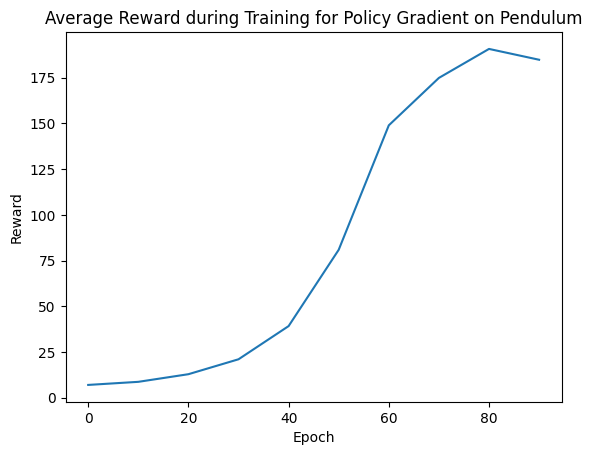

test 0, success False, reward 125.0
test 1, success False, reward 129.0
test 2, success False, reward 170.0
test 3, success False, reward 129.0
test 4, success False, reward 131.0
test 5, success False, reward 185.0
test 6, success False, reward 151.0
test 7, success False, reward 136.0
test 8, success False, reward 173.0
test 9, success False, reward 150.0
test 10, success False, reward 117.0
test 11, success False, reward 153.0
test 12, success False, reward 180.0
test 13, success False, reward 174.0
test 14, success False, reward 144.0
test 15, success False, reward 162.0
test 16, success False, reward 165.0
test 17, success False, reward 195.0
test 18, success False, reward 139.0
test 19, success False, reward 175.0
test 20, success False, reward 189.0
test 21, success False, reward 189.0
test 22, success False, reward 156.0
test 23, success False, reward 183.0
test 24, success False, reward 133.0
test 25, success False, reward 169.0
test 26, success False, reward 167.0
test 27, su

In [39]:
args = Args('pg', 'pendulum', seed=1)
result = train_and_eval(args)


### 6b. Actor-Critic — Pendulum


step 5000, batch_r 1.0, critic_l 0.9705, actor_l 0.0027, actor_ent 0, alpha_l 0
eval step 5000, average episode reward 26.8, average episode length 26.8, success rate 0.0
step 10000, batch_r 1.0, critic_l 0.3347, actor_l -20.1176, actor_ent 0, alpha_l 0
eval step 10020, average episode reward 55.3, average episode length 55.3, success rate 0.0
step 15000, batch_r 1.0, critic_l 0.1497, actor_l -28.162, actor_ent 0, alpha_l 0
eval step 15025, average episode reward 82.0, average episode length 82.0, success rate 0.0
step 20000, batch_r 1.0, critic_l 0.0218, actor_l -38.5419, actor_ent 0, alpha_l 0
eval step 20062, average episode reward 200.0, average episode length 200.0, success rate 1.0
step 25000, batch_r 1.0, critic_l 0.0024, actor_l -62.1834, actor_ent 0, alpha_l 0
eval step 25262, average episode reward 200.0, average episode length 200.0, success rate 1.0


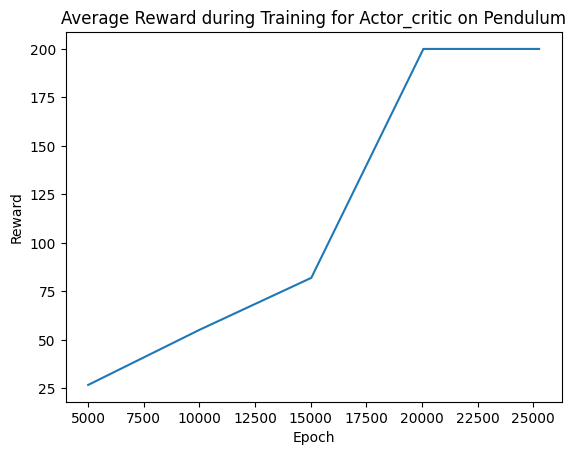

eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 143.0, episode length 143
eval episode reward 140.0, episode length 140
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 140.0, episode length 140
eval episode reward 200.0, episode length 200
eval episode reward 143.0, episode

In [57]:
args = Args('actor_critic', 'pendulum')
result = train_and_eval(args)


### 6c. SAC — Pendulum


step 5000, batch_r 1.0, critic_l 1.815, actor_l 0.0072, actor_ent -0.2878, alpha_l 0.0712
eval step 5000, average episode reward 24.7, average episode length 24.7
step 10000, batch_r 1.0, critic_l 2.2134, actor_l -18.5243, actor_ent -0.3952, alpha_l 0.0236
eval step 10014, average episode reward 75.9, average episode length 75.9
step 15000, batch_r 1.0, critic_l 0.0279, actor_l -27.4984, actor_ent -0.9288, alpha_l 0.0014
eval step 15114, average episode reward 200.0, average episode length 200.0
step 20000, batch_r 1.0, critic_l 0.0066, actor_l -47.5305, actor_ent -0.555, alpha_l 0.0035
eval step 20259, average episode reward 200.0, average episode length 200.0
step 25000, batch_r 1.0, critic_l 0.004, actor_l -63.1571, actor_ent -0.4476, alpha_l 0.0011
eval step 25459, average episode reward 200.0, average episode length 200.0
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200.0, episode length 200
eval episode reward 200

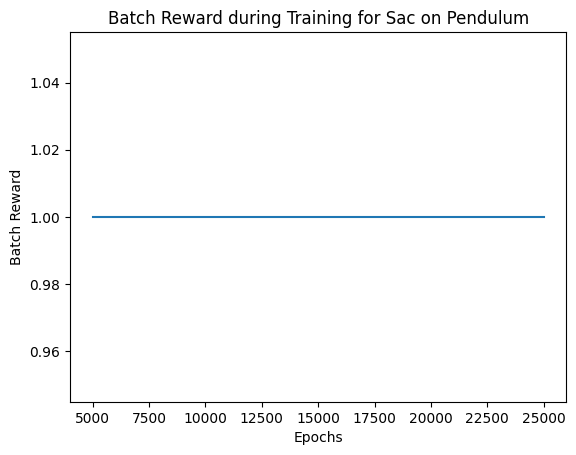

In [11]:
args = Args('sac', 'pendulum')
result = train_and_eval(args)


### 6d. Actor-Critic — Ant


step 5000, batch_r -0.3101, critic_l 0.6697, actor_l 0.0253, actor_ent 0, alpha_l 0
eval step 5000, average episode reward 487.3709893865389, average episode length 500.0, success rate 1.0
step 10000, batch_r 0.5718, critic_l 0.0159, actor_l -15.3406, actor_ent 0, alpha_l 0
eval step 10229, average episode reward 184.33811212576515, average episode length 465.2, success rate 0.8
step 15000, batch_r 0.8304, critic_l 0.0055, actor_l -33.738, actor_ent 0, alpha_l 0
eval step 15729, average episode reward 397.2207480446018, average episode length 500.0, success rate 1.0
step 20000, batch_r 0.6231, critic_l 0.0364, actor_l -46.1117, actor_ent 0, alpha_l 0
eval step 21229, average episode reward 348.4018318838438, average episode length 500.0, success rate 1.0
step 25000, batch_r 0.8039, critic_l 0.0132, actor_l -57.1128, actor_ent 0, alpha_l 0
eval step 26729, average episode reward 267.37542718905513, average episode length 500.0, success rate 1.0


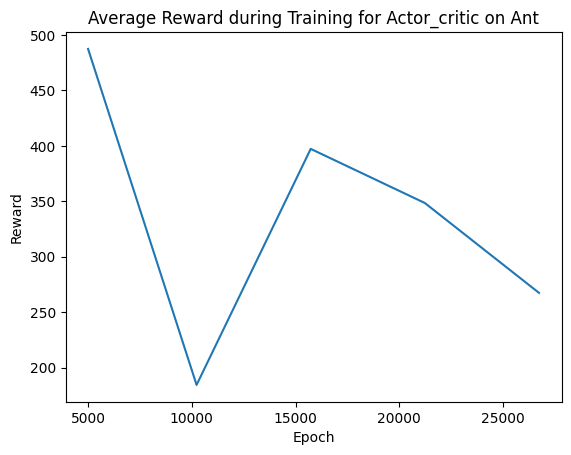

eval episode reward 249.0777861753935, episode length 500
eval episode reward 281.84233953792227, episode length 500
eval episode reward 338.1322668321747, episode length 500
eval episode reward 391.7273048998554, episode length 500
eval episode reward 372.30549998518086, episode length 500
eval episode reward 383.50383432186436, episode length 500
eval episode reward 414.6689370223481, episode length 500
eval episode reward 371.0615551426996, episode length 500
eval episode reward 216.43130399346882, episode length 500
eval episode reward 392.8312684494409, episode length 500
eval episode reward 391.7225091064888, episode length 500
eval episode reward 390.75744963630285, episode length 500
eval episode reward 394.38199666828064, episode length 500
eval episode reward 384.28413970677275, episode length 500
eval episode reward 297.21931312325137, episode length 500
eval episode reward 341.99739858916007, episode length 500
eval episode reward 345.75220109380984, episode length 500
eval

In [79]:
args = Args('actor_critic', 'ant')
result = train_and_eval(args)


### 6e. SAC — Ant


step 5000, batch_r -0.3276, critic_l 5.1185, actor_l 1.0423, actor_ent -3.9706, alpha_l 0.4029
eval step 5000, average episode reward 472.5994234419944, average episode length 500.0, success rate 1.0
step 10000, batch_r 0.4058, critic_l 1.4239, actor_l -9.4852, actor_ent -4.7972, alpha_l 0.1162
eval step 10497, average episode reward 274.6565826171779, average episode length 368.6, success rate 1.0
step 15000, batch_r 0.7284, critic_l 0.7154, actor_l -23.2466, actor_ent -8.1903, alpha_l -0.0053
eval step 15903, average episode reward 345.1416476458164, average episode length 413.3, success rate 1.0
step 20000, batch_r 0.825, critic_l 1.8459, actor_l -36.9483, actor_ent -7.7457, alpha_l 0.0096
eval step 21327, average episode reward 319.29744571019074, average episode length 384.9, success rate 1.0
step 25000, batch_r 0.8401, critic_l 2.7602, actor_l -44.856, actor_ent -8.3223, alpha_l -0.0135
eval step 26346, average episode reward 278.7402305983934, average episode length 344.9, succe

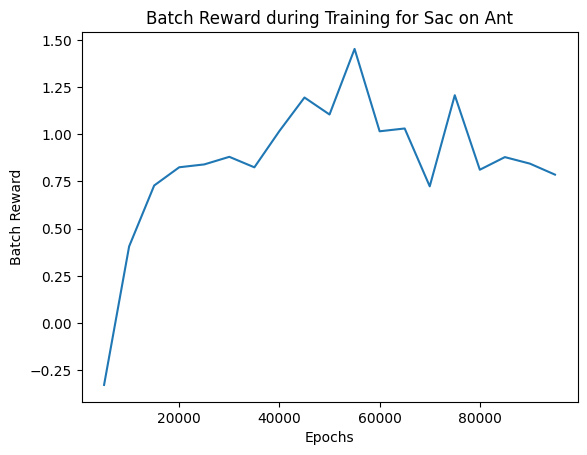

In [62]:
args = Args('sac', 'ant')
result = train_and_eval(args)


---
## Submission

Download the trained `.pth` weights below and submit them along with your filled-in `policy_gradient.py`, `actor_critic.py`, and `sac.py`.


In [ ]:
import glob

# If running on Google Colab, trigger download "of weight files
try:
    from google.colab import files
    for f in glob.glob("*.pth"):
        files.download(f)
except ImportError:
    print("Not on Colab. Weights are saved in the current directory:")
    for f in glob.glob("*.pth"):
        print(" ", f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>